# Regresión Logística: ¿Se otorgará una beca según el nivel de participación?
En este ejemplo, utilizaremos **regresión logística** para predecir si un estudiante recibirá una beca, teniendo en cuenta su nivel de participación en actividades extracurriculares.

Este es un caso típico de **clasificación binaria**:
- **1**: el estudiante recibe la beca
- **0**: el estudiante no la recibe

El objetivo es construir un modelo que estime esta probabilidad de forma precisa, y que permita tomar decisiones educativas informadas.

#Importar Librerias

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_score, recall_score,
                              f1_score, classification_report)

#Cargar detos de la participacion de becas


In [10]:
ruta = 'participacion_beca.csv'
df = pd.read_csv(ruta)
df

,Participación (%),Beca otorgada
0,5,0
1,10,0
2,15,0
3,20,0
4,25,1
5,30,1
6,40,1
7,50,1
8,60,1
9,70,1


# Visualización inicial

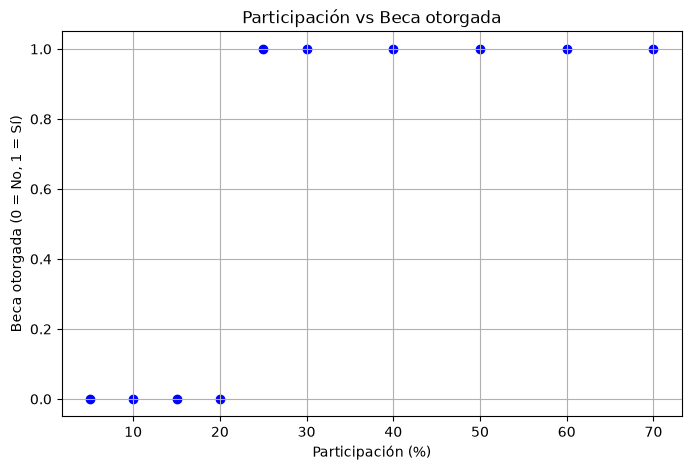

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Participación (%)'], df['Beca otorgada'], color='blue')
plt.xlabel('Participación (%)')
plt.ylabel('Beca otorgada (0 = No, 1 = Sí)')
plt.title('Participación vs Beca otorgada')
plt.grid(True)
plt.show()

#Separar X e y

In [12]:
X = df[['Participación (%)']]
y = df['Beca otorgada']

#Separar en entrenamiento y prueba

 separamos el dataset en un conjunto de **entrenamiento (80%)** y uno de **prueba (20%)** con `train_test_split`. Usamos `stratify=y` para que la proporción de becas otorgadas/no otorgadas se mantenga similar en ambos conjuntos.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (8, 1)
X_test : (2, 1)


#Crear el Modelo

#Entrenar

In [14]:
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#Predecir

Esto es una predicción sobre un caso **hipotético** (28% de participación), no sobre el conjunto de prueba — sirve para ver cómo se usa el modelo ya entrenado sobre un dato nuevo cualquiera.

In [15]:
nueva_participacion = pd.DataFrame({'Participación (%)': [28]})
proba = modelo.predict_proba(nueva_participacion)[:, 1][0]
prediccion = modelo.predict(nueva_participacion)[0]

print(f'Probabilidad estimada de obtener la beca: {proba:.2f}')
print('Predicción:', 'Beca otorgada' if prediccion == 1 else 'Beca no otorgada')

Probabilidad estimada de obtener la beca: 0.98
Predicción: Beca otorgada


#Graficar

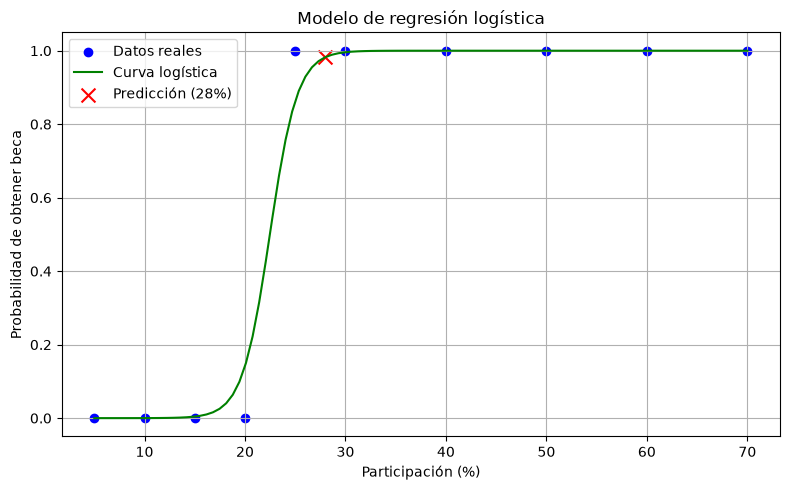

In [16]:
# Graficar la curva logística
valores_x = np.linspace(df['Participación (%)'].min(), df['Participación (%)'].max(), 100)
valores_df = pd.DataFrame(valores_x, columns=['Participación (%)'])
probas = modelo.predict_proba(valores_df)[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(df['Participación (%)'], df['Beca otorgada'], color='blue', label='Datos reales')
plt.plot(valores_x, probas, color='green', label='Curva logística')
plt.scatter([28], [proba], color='red', marker='x', s=100, label='Predicción (28%)')
plt.xlabel('Participación (%)')
plt.ylabel('Probabilidad de obtener beca')
plt.title('Modelo de regresión logística')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Comparar predicciones en el conjunto de prueba

Antes de ver las métricas agregadas, comparamos fila por fila lo que predice el modelo sobre `X_test` (datos que **no** vio al entrenar) contra el valor real.

In [17]:
comparacion = pd.DataFrame({
    'Participación (%)': X_test['Participación (%)'].values,
    'Beca real': y_test.values,
    'Beca predicha': modelo.predict(X_test),
    'Probabilidad predicha': modelo.predict_proba(X_test)[:, 1].round(2)
})
comparacion

,Participación (%),Beca real,Beca predicha,Probabilidad predicha
0,15,0,0,0.0
1,40,1,1,1.0


### Evaluación del modelo con Matriz de Confusión y Meétricas



Incluye, para cada clase (en este caso, `0 = no beca`, `1 = beca`):

- **precision**: ¿De todas las veces que el modelo predijo esta clase, cuántas veces acertó?  
  Fórmula: `TP / (TP + FP)`

- **recall**: ¿De todos los casos reales de esta clase, cuántos detectó correctamente?  
  Fórmula: `TP / (TP + FN)`

- **f1-score**: Promedio armónico entre precision y recall. Es útil cuando hay clases desbalanceadas.  
  Fórmula: `2 * (precision * recall) / (precision + recall)`




### ¿Qué es la matriz de confusión?

La **matriz de confusión** es una tabla que permite analizar cómo se comportó un modelo de clasificación.  
Compara los **valores reales** (verdaderos) con los **valores predichos** por el modelo.

En un problema binario como este (1 = beca, 0 = no beca), la matriz tiene 4 componentes:

|                         | Predijo 0 (No beca)     | Predijo 1 (Beca)         |
|-------------------------|-------------------------|--------------------------|
| **Real = 0 (No beca)**  | Verdadero Negativo (TN) | Falso Positivo (FP)      |
| **Real = 1 (Beca)**     | Falso Negativo (FN)     | Verdadero Positivo (TP)  |


#Graficar la matriz de Confusión

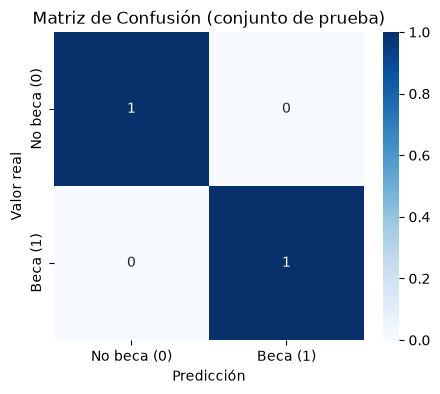

Accuracy:  1.00
Precision: 1.00
Recall:    1.00
F1-score:  1.00

Reporte de clasificación:
              precision    recall  f1-score   support

 No beca (0)       1.00      1.00      1.00         1
    Beca (1)       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [18]:
y_pred = modelo.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No beca (0)', 'Beca (1)'],
            yticklabels=['No beca (0)', 'Beca (1)'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión (conjunto de prueba)')
plt.show()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f'Accuracy:  {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall:    {recall:.2f}')
print(f'F1-score:  {f1:.2f}')
print()
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=['No beca (0)', 'Beca (1)'], zero_division=0))